# Solving on the graph: a simple Euler solver (WORK IN PROGRESS)

**This notebook is a scope outline, not a finished tutorial.** The
numerical method, time-stepping, and JAX architecture are deliberately
not designed yet -- that's its own planning pass, informed by actually
seeing the graph data in practice via
[`Plot3D_Flatten.ipynb`](Plot3D_Flatten.ipynb).

The plan:

1. A **converging-diverging duct** -- a genuine single-block 3D mesh (not
   a hand-waved 1D array), built with the same `duct_block` generator from
   `Plot3D_Flatten.ipynb`'s "Simple block" section, given a *variable*
   radius/height profile instead of a constant one.
2. Flatten it with `flatten_mesh()`, exactly as in the other notebook --
   the physics below only ever touches `face_owner`/`face_neighbor`/
   `face_area`/`face_normal`/`cell_volume`, so the graph is exercised for
   real even though the flow is quasi-1D (every `(j, k)` at a given `i`
   behaves identically).
3. An **explicit finite-volume Euler update** with a simple, robust flux
   (Rusanov / local-Lax-Friedrichs is the leading candidate -- it avoids a
   Roe solver's entropy-fix complexity, which matters for a "keep it
   simple" tutorial).
4. **JAX** for the vectorized per-face flux evaluation and per-cell
   update. Not a project dependency (see `pyproject.toml`) -- installed
   the same way `plot3d` itself is, with `!pip install jax`.
5. Validate against the analytic quasi-1D isentropic nozzle solution.

Below is only step 1 -- the mesh generator, reused and demonstrated with a
real converging-diverging profile. Steps 2-5 are not implemented yet.


## Install


In [1]:
!pip install "plot3d>=1.10.0"


zsh:1: command not found: pip


In [2]:
import numpy as np
import matplotlib.pyplot as plt

from plot3d import Block, plot_blocks
from plot3d.connectivity import connectivity
from plot3d import flatten_mesh


## The duct generator, reused

Identical to `Plot3D_Flatten.ipynb`'s `duct_block` -- `height` accepts a
callable, which is exactly what a converging-diverging (Laval nozzle)
profile needs.


duct block: (41, 9, 3) nodes


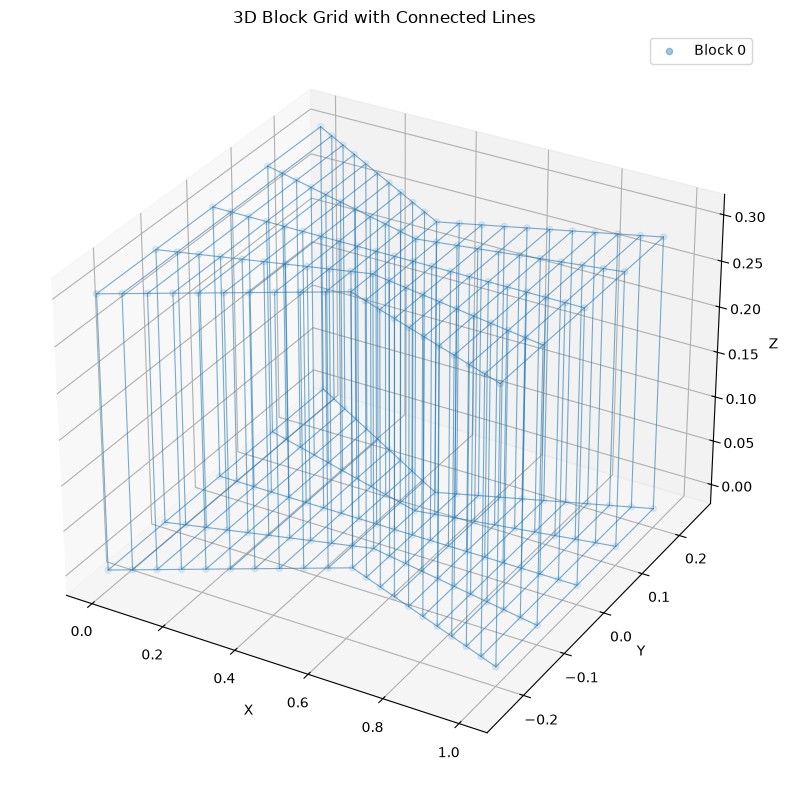

In [3]:
def duct_block(x0, x1, nx, height, ny=9, nz=5, depth=0.3):
    """A single-block rectangular duct. `height` is the full duct height at
    each x station: a constant for a straight duct, or a callable height(x)
    for a variable cross-section."""
    x = np.linspace(x0, x1, nx)
    z = np.linspace(0.0, depth, nz)
    X = np.zeros((nx, ny, nz))
    Y = np.zeros_like(X)
    Z = np.zeros_like(X)
    for i in range(nx):
        h = height(x[i]) if callable(height) else height
        y = np.linspace(-h / 2, h / 2, ny)
        for j in range(ny):
            for k in range(nz):
                X[i, j, k] = x[i]
                Y[i, j, k] = y[j]
                Z[i, j, k] = z[k]
    return Block(X, Y, Z)


def cd_nozzle_height(x, h_inlet=0.5, h_throat=0.2, h_exit=0.4, x_throat=0.5):
    """A simple converging-diverging (Laval) height profile: linear taper
    from h_inlet down to h_throat at x_throat, then linear back up to
    h_exit. Swap in a smoother profile later if the flux scheme needs it."""
    if x <= x_throat:
        t = x / x_throat
        return h_inlet + t * (h_throat - h_inlet)
    else:
        t = (x - x_throat) / (1.0 - x_throat)
        return h_throat + t * (h_exit - h_throat)


duct = duct_block(0.0, 1.0, 41, height=cd_nozzle_height, ny=9, nz=3)
print(f"duct block: ({duct.IMAX}, {duct.JMAX}, {duct.KMAX}) nodes")
plot_blocks([duct])


## The height profile, for sanity-checking against the mesh above


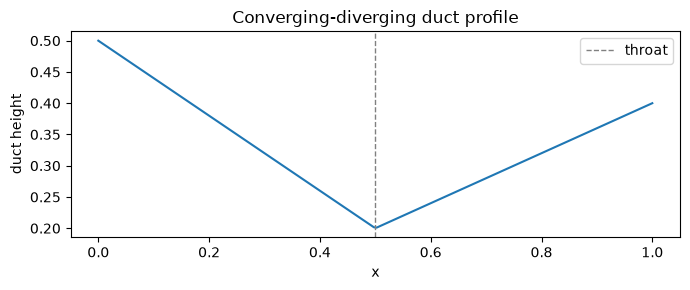

In [4]:
xs = np.linspace(0.0, 1.0, 200)
hs = [cd_nozzle_height(x) for x in xs]
plt.figure(figsize=(7, 3))
plt.plot(xs, hs)
plt.axvline(0.5, color="gray", linestyle="--", linewidth=1, label="throat")
plt.xlabel("x")
plt.ylabel("duct height")
plt.title("Converging-diverging duct profile")
plt.legend()
plt.tight_layout()
plt.show()


## The graph, built the same way as `Plot3D_Flatten.ipynb`

This confirms the mesh and the flattener work together for this geometry
-- no solver yet, just the graph the solver will eventually run on.


In [5]:
face_matches, outer_faces = connectivity([duct])
fmesh = flatten_mesh([duct], face_matches, outer_faces)
print(fmesh.summary())


0it [00:00, ?it/s]

0it [00:00, ?it/s]

Phase 3: Fresh-face validation...
  Phase 3 done (0 new matches)


Calculating the volumes:   0%|          | 0/2 [00:00<?, ?it/s]

Calculating the volumes: 100%|██████████| 2/2 [00:00<00:00, 339.33it/s]

FlatMesh: Nc=640 Nf=2336 Nn=1107
  total volume = 0.0975
  total boundary surface area = 1.53915
  periodic faces = 0
  boundary faces per surface:
    id=1 (1): 320
    id=2 (2): 16
    id=3 (3): 320
    id=4 (4): 80
    id=5 (5): 80
    id=6 (6): 16


## Coming next (not yet implemented)

- Tag `outer_faces` for real: inlet at `x=0`, outlet at `x=1`, walls
  everywhere else (the duct's `y`/`z` faces).
- Pick and implement a Rusanov (or similar) flux function, vectorized
  over all interior faces at once.
- An explicit time-marching loop (`cell_state[t+1] = cell_state[t] -
  dt/cell_volume * sum(flux * face_area_mag)` over each cell's faces),
  first in plain numpy, then ported to JAX (`jax.jit`, maybe `jax.vmap`
  over faces) once the update is correct.
- Run to a steady state, compare Mach number and pressure along the duct
  centerline against the analytic quasi-1D isentropic solution.
